## 0. Подключение библиотек.

In [ ]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

## 1. Подготовка датасета LEGO наборов.

In [ ]:
df = pd.read_csv("lego-sets.csv", sep=';')
df = df.drop(columns=["avg_year", "avg_price"])
df = df.drop_duplicates(subset=["name"], keep="first")
df = df.reset_index(drop=True)
df.head(10)

,name,theme,Subtheme,Pieces,minifigs,Year,Retail price
0,10123 LEGO Star Wars Cloud City,Star Wars,Episode V,698,7,2003,99.99
1,75338 LEGO Star Wars Andor Ambush on Ferrix,Star Wars,Andor,679,3,2022,69.99
2,75335 LEGO Star Wars Jedi Fallen Order BD-1,Star Wars,Jedi Fallen Order,1062,1,2022,99.99
3,40558 LEGO Star Wars Clone Trooper Command Sta...,Star Wars,Episode II,66,3,2022,14.99
4,75330 LEGO Star Wars Dagobah Jedi Training Dio...,Star Wars,Diorama Collection,1000,3,2022,89.99
5,75324 LEGO Star Wars The Mandalorian Dark Troo...,Star Wars,The Mandalorian,166,4,2022,34.99
6,75343 LEGO Star Wars Helmet Collection Dark Tr...,Star Wars,Helmet Collection,693,0,2022,69.99
7,75339 LEGO Star Wars Death Star Trash Compacto...,Star Wars,Diorama Collection,802,6,2022,89.99
8,75329 LEGO Star Wars Death Star Trench Run Dio...,Star Wars,Diorama Collection,665,0,2022,69.99
9,40557 LEGO Star Wars Defence of Hoth,Star Wars,Episode V,64,3,2022,14.99


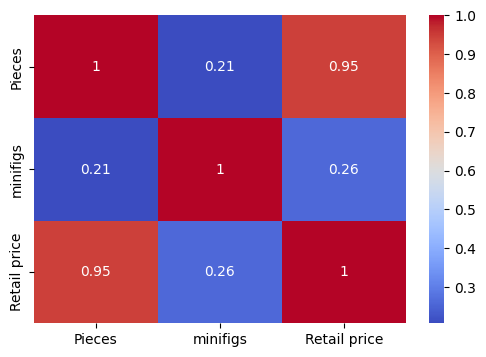

In [ ]:
plt.figure(figsize=(6,4))
sns.heatmap(df[["Pieces", "minifigs", "Retail price"]].corr(), annot=True, cmap="coolwarm")
plt.show()

## 2. Baseline.

In [ ]:
def baselineLegoSets(df):
    if df["Pieces"] < 250:
        return 0
    elif df["Pieces"] < 900:
        return 1
    else:
        return 2

df = df.dropna(subset=["Pieces", "minifigs", "Retail price"])
df["clustersLegoBaseline"] = df.apply(baselineLegoSets, axis=1)

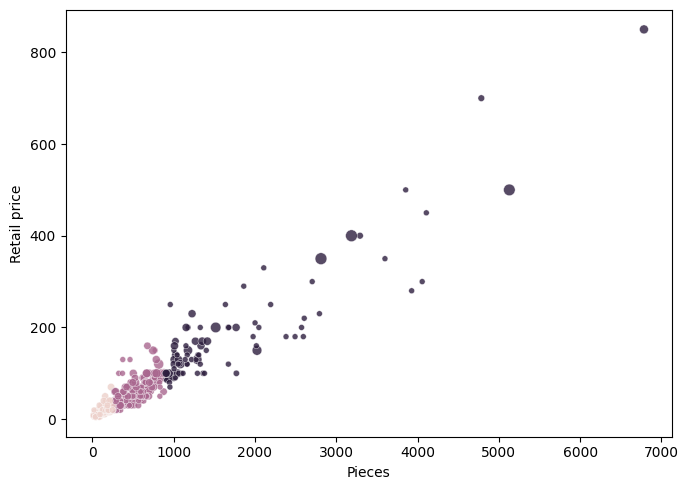

Силуэт
0.42


In [ ]:
plt.figure(figsize=(7,5))
sns.scatterplot(data=df, x="Pieces", y="Retail price",hue="clustersLegoBaseline", size="minifigs",alpha=0.8, legend=False)
plt.xlabel("Pieces")
plt.ylabel("Retail price")
plt.tight_layout()
plt.show()

x = df[["Pieces", "minifigs", "Retail price"]].to_numpy()
baselineCluster = df["clustersLegoBaseline"].to_numpy()
metric_sil_Baseline = silhouette_score(x, baselineCluster)

print("Силуэт")
print(round(metric_sil_Baseline, 2))

## 3. K-Means.

Силуэт
0.66


<Axes: >

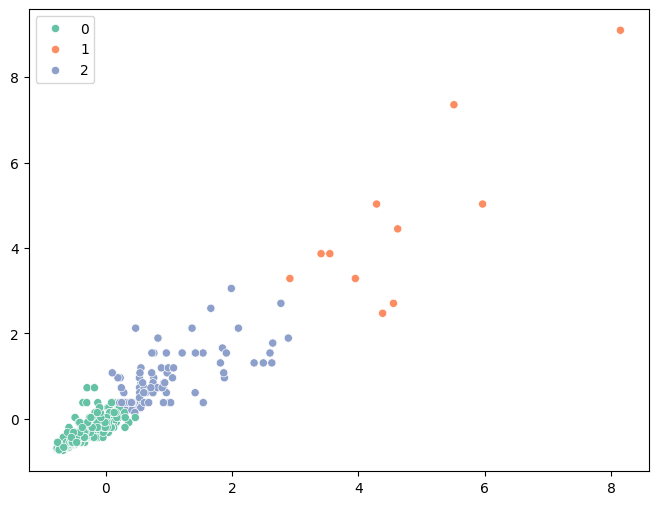

In [ ]:
xData = df[["Pieces", "Retail price", ]].copy()

scaler = StandardScaler()
dataTrain_X = scaler.fit_transform(xData)
model = KMeans(n_clusters=3, random_state = 45)
model.fit(dataTrain_X)
metric_sil = silhouette_score(dataTrain_X, model.labels_)
print("Силуэт")
print(round(metric_sil,2))
plt.figure(figsize=(8,6))
sns.scatterplot(x=dataTrain_X[:, 0],y=dataTrain_X[:, 1],hue=model.labels_,palette="Set2",s=35)

## 4. Реализация K-Means.

In [ ]:
def myKmeans(data_X, k, valueIters=150, stop="stop"):

    dataMatrix = np.asarray(data_X, dtype=float)
    f, col = dataMatrix.shape
    randomValue = np.random.default_rng()
    matrixClasters = np.empty((k, col))
    matrixClasters[0] = dataMatrix[randomValue.integers(f)]
    dist_Sq = np.sum((dataMatrix - matrixClasters[0])**2, axis=1)

    for i in range(1, k):
        p = dist_Sq / dist_Sq.sum()
        matrixClasters[i] = dataMatrix[randomValue.choice(f, p=p)]
        dist_Sq = np.minimum(dist_Sq, np.sum((dataMatrix - matrixClasters[i])**2, axis=1))

    x_Sq = (dataMatrix * dataMatrix).sum(axis=1, keepdims=True)
    iterValue = None
    clust = None

    for j in range(1, valueIters + 1):
        centersNormal = (matrixClasters * matrixClasters).sum(axis=1)[None, :]
        valueDist = x_Sq + centersNormal - 2.0 * np.dot(dataMatrix, matrixClasters.T)
        clusterLabelsValue = valueDist.argmin(axis=1)
        itValue = valueDist[np.arange(f), clusterLabelsValue].sum()

        if clust is not None and np.array_equal(clusterLabelsValue, clust):
            clust = clusterLabelsValue
            break
        clust = clusterLabelsValue

        if stop == "itValue" and iterValue is not None:
            gain = (iterValue - itValue) / max(iterValue, 1.0)
            if gain <= 1e-4:
                break
        iterValue = itValue
        matrixClastersNew = np.zeros_like(matrixClasters)
        np.add.at(matrixClastersNew, clusterLabelsValue, dataMatrix)
        c = np.bincount(clusterLabelsValue, minlength=k).astype(float)
        check = c > 0
        matrixClastersNew[check] /= c[check, None]
        if not np.all(check):
            midLongPoint = valueDist.min(axis=1)
            index = np.argsort(midLongPoint)[::-1]
            emptIndex = np.where(~check)[0]
            for jj, point_idx in zip(emptIndex, index):
                matrixClastersNew[jj] = dataMatrix[point_idx]

        if stop == "stop":
            stopOver = np.linalg.norm(matrixClastersNew - matrixClasters, axis=1).max()
            matrixClasters = matrixClastersNew
            if stopOver <= 1e-3:
                break
        else:
            matrixClasters = matrixClastersNew

    return clusterLabelsValue, matrixClasters, itValue, j


Силуэт
0.65


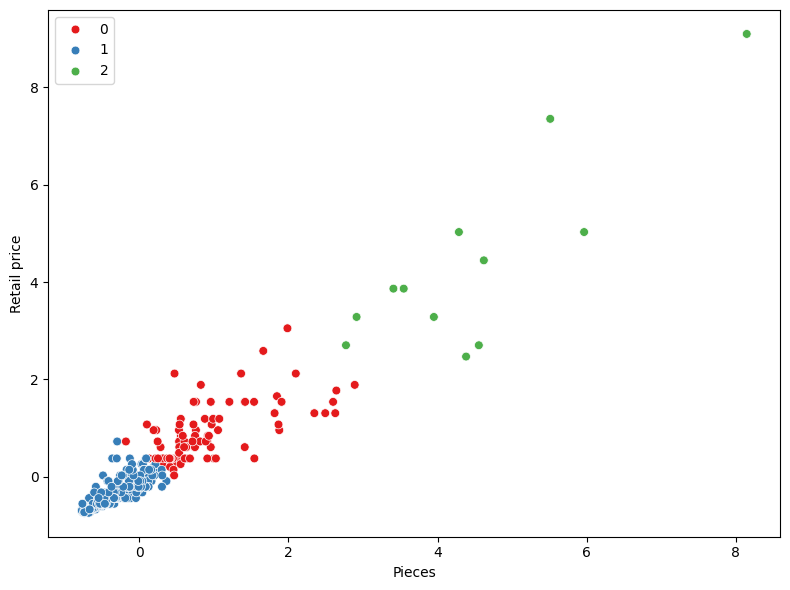

In [ ]:
labels, centers, itValue, valueIterations = myKmeans(dataTrain_X, k=3, valueIters=300)
metric_sil = silhouette_score(dataTrain_X, labels)
print("Силуэт")
print(round(metric_sil, 2))
plt.figure(figsize=(8,6))
sns.scatterplot(x=dataTrain_X[:, 0],y=dataTrain_X[:, 1],hue=labels,palette="Set1",s=40)
plt.xlabel("Pieces")
plt.ylabel("Retail price")
plt.tight_layout()
plt.show()